# Generates biomes based on Fay and McKinley 2014 from observations

In [1]:
%matplotlib inline
# import warnings
# warnings.filterwarnings('ignore')
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

import pandas as pd

import xesmf #for regridding
xr.set_options(keep_attrs=True)
import regionmask #for generating 1° ocean mask
import m6toolbox

### Make a standard 1° ones masks for masking, etc. (one for lons -180 to 180 and one for lons 0 to 360)

In [2]:
ones2 = np.full((180,360),1,dtype=int)
ones2 = xr.DataArray(ones2,dims=('lat','lon'))
ones2['lat'] = np.arange(-89.5, 90, 1)
ones2['lon'] = np.arange(0.5, 360, 1)

### Read in the standard 1° basin mask

In [3]:
# Define the 1-degree latitude and longitude points
lon = np.arange(-179.5, 180, 1)
lat = np.arange(-89.5, 90, 1)

# Create the land mask using Natural Earth data (default resolution is 1:110m)
# The mask will be boolean (True for land) on the specified grid
land_mask = regionmask.defined_regions.natural_earth_v5_1_2.land_110.mask(lon, lat)
land_mask = land_mask.where(land_mask==0, other=1)

In [4]:
ones = np.full((180,360),1,dtype=int)
ones = xr.DataArray(ones,dims=('lat','lon'))
ones['lat'] = np.arange(-89.5, 90, 1)
ones['lon'] = np.arange(-179.5, 180, 1)
ones = ones.where(land_mask == 1)

In [5]:
### forth, get the major basins mask, created using 'make_major_basins_mask.ipynb'
major_basins = xr.open_dataset('major_basins_1x1.nc')

major_basins = major_basins.basin.values
major_basins = xr.DataArray(major_basins, dims=('lat','lon'))

# Read in observational data monthly climatologies that have been regridded to 1°

In [6]:
file = 'Obs4biomes.nc'
ds_obs = xr.open_dataset(file)

In [7]:
ds_obs

<xarray.Dataset> Size: 25MB
Dimensions:  (lat: 180, lon: 360, month: 12)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    MLD      (lat, lon, month) float64 6MB ...
    Chl      (lat, lon, month) float64 6MB ...
    Ice      (lat, lon, month) float64 6MB ...
    SST      (lat, lon, month) float64 6MB ...

### First step from the FM2014 Methods is this (but this is not described further), we will use major basins mask:
"The global open ocean is first divided into ocean basins (Atlantic, Pacific, Indian, and Southern Ocean)"

### The next step is applying criteria in Table 1 of FM2014:
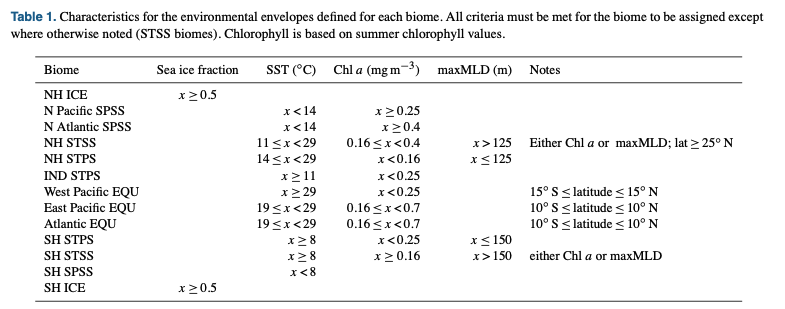

### Also important: 
Biome assignments are made from pole to Equator for each hemisphere, beginning with the Northern Hemisphere (NH). This order is important as some biome’s criteria are not mutually exclusive (specifically the EQU and South Pacific and Atlantic STPS biomes).


### Create an empty BIOME dataset, each biome will be a variable:
• 1 = within biome

• 0 = outside biome

• Nan on land

In [8]:
ds_biome = xr.Dataset()

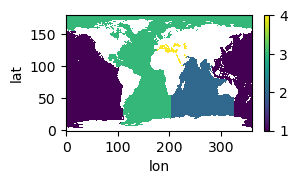

In [9]:
major_basins.plot(figsize=(3,1.5))

# A few precalculations....

### Assign basins

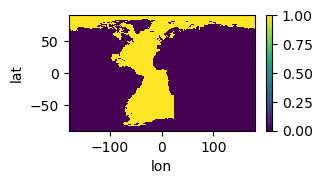

In [10]:
Atlantic = ones.where(major_basins == 3, other=0)
#.where(major_basins.basin == 3) #ones.where(ds_grid.REGION_MASK >= 5, other=0).where(ds_grid.REGION_MASK<10, other=0)
Atlantic.plot(figsize=(3,1.5))

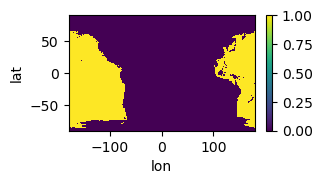

In [11]:
Pacific = ones.where(major_basins == 1, other=0)
Pacific.plot(figsize=(3,1.5))

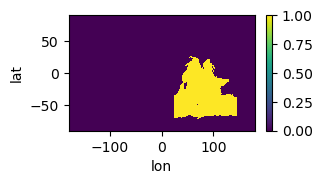

In [12]:
Indian = ones.where(major_basins == 2, other=0)
Indian.plot(figsize=(3,1.5))

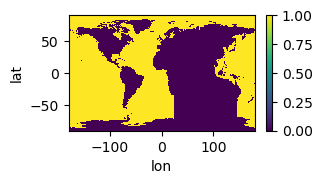

In [13]:
Atlantic_Pacific = Atlantic + Pacific
Atlantic_Pacific.plot(figsize=(3,1.5))

### Compute mean NH "spring/summer" chlorophyll concentration: April - September, all areas north of 10°S

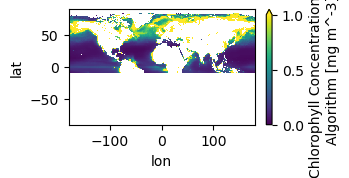

In [14]:
chl_NH_field = ds_obs.Chl.isel(month=slice(3,9)).mean(dim='month').where(ds_obs.lat > -10)
chl_NH_field.plot(vmin=0,vmax=1,figsize=(3,1.5))

### Compute SH spring/summer chl field: December to March, all regions south of 10°S

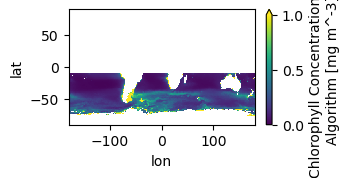

In [15]:
chl_SH_field = (ds_obs.Chl.isel(month=11) + ds_obs.Chl.isel(month=0) + ds_obs.Chl.isel(month=1) + ds_obs.Chl.isel(month=2)) / 4.
chl_SH_field = chl_SH_field.where(land_mask == 1).where(ds_obs.lat <= -10)
chl_SH_field.plot(vmin=0,vmax=1, figsize=(3,1.5))

### Combine NH and SH chlorophyll fields so we can have just one for masking

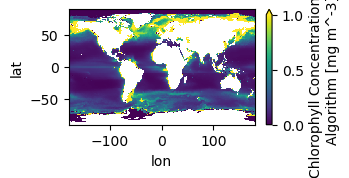

In [16]:
tmp1 = chl_NH_field.where(chl_NH_field > 0, other=0)
tmp2 = chl_SH_field.where(chl_SH_field > 0, other=0)

chl = (tmp1 + tmp2).where(land_mask == 1)
chl.plot(vmin=0,vmax=1, figsize=(3,1.5))

### Compute SST field for masking. I think it's just annual mean, based on this sentence:

"For mean SST and sea ice fraction criteria, annual climatologies for years 1998–2010 are averaged. Specific criteria for each biome are presented in Table 1."

In [17]:
sst = ds_obs.SST.mean(dim='month')

### Compute max of the maxMLD to use for masking

In [18]:
mld = ds_obs.MLD.max(dim='month')

### Compute maximum ice fraction over the course of the year

In [19]:
ice = ds_obs.Ice.max(dim='month')

### Important thresholds

In [20]:
### SST threholds
SPSS_NH_temp_upthres = 14

STSS_NH_temp_lothres = 11
STSS_NH_temp_upthres = 29

STPS_NH_temp_lothres = 14
STPS_NH_temp_upthres = 29

STPS_Ind_temp_lothres = 11

WPacEq_temp_lothres = 29
EPacEq_temp_lothres = 19
EPacEq_temp_upthres = 29
AtlEq_temp_lothres = 19
AtlEq_temp_upthres = 29

SPSS_SH_temp_upthres = 8
STSS_SH_temp_lothres = 8
STPS_SH_temp_lothres = 8

In [21]:
### Chl thresholds
SPSS_NPac_chl_lothres = 0.25
SPSS_NAtl_chl_lothres = 0.4

STSS_NH_chl_lothres = 0.16
STSS_NH_chl_upthres = 0.4

STPS_NH_chl_upthres = 0.16

STPS_Ind_chl_upthres = 0.25

WPacEq_chl_upthres = 0.25
EPacEq_chl_lothres = 0.16
EPacEq_chl_upthres = 0.7
AtlEq_chl_lothres = 0.16
AtlEq_chl_upthres = 0.7

STSS_SH_chl_lothres = 0.16

STPS_SH_chl_upthres = 0.25

In [22]:
### maxMLD thresholds

STSS_NH_mld_lothres = 125

STPS_NH_mld_upthres = 125

STSS_SH_mld_lothres = 150

STPS_SH_mld_upthres = 150

In [23]:
### ice thresholds

ICE_lothres = 0.5

# BIOME ASSIGNMENTS

### NH ICE biome

"A minimum threshold of 0.5 fractional cover- age in any month of the year designates the ICE biome."

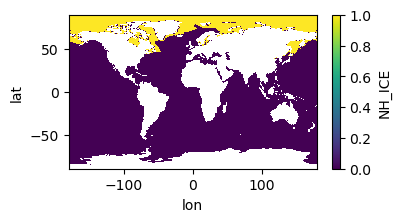

In [24]:
ds_biome['NH_ICE'] = ones.where(ice > ICE_lothres).where(ds_obs.lat > 0)

ds_biome['NH_ICE'] = ds_biome['NH_ICE'].where(ds_biome['NH_ICE'] > 0, other = 0)

ds_biome['NH_ICE'] = ds_biome['NH_ICE'].where(ones > 0).compute()

ds_biome['NH_ICE'].plot(figsize=(4,2))

### SPSS NH biomes: Alantic and Pacific

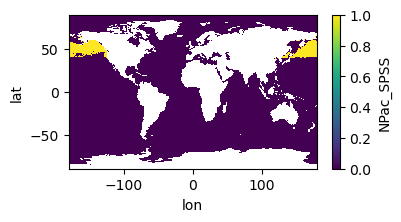

In [25]:
ds_biome['NPac_SPSS'] = ones.where(sst < SPSS_NH_temp_upthres).where(chl >= SPSS_NPac_chl_lothres).where(Pacific == 1).where(ds_obs.lat > 0)

### Lastly, make sure it doesn't conflict with the NH ICE BIOME
ds_biome['NPac_SPSS'] = ds_biome['NPac_SPSS'].where(ds_biome['NH_ICE'] < 1)

ds_biome['NPac_SPSS'] = ds_biome['NPac_SPSS'].where(ds_biome['NPac_SPSS'] > 0, other = 0)

ds_biome['NPac_SPSS'] = ds_biome['NPac_SPSS'].where(ones > 0).compute()

ds_biome['NPac_SPSS'].plot(figsize=(4,2))

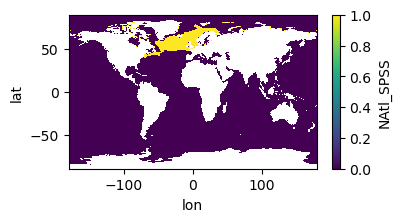

In [26]:
ds_biome['NAtl_SPSS'] = ones.where(sst < SPSS_NH_temp_upthres).where(chl >= SPSS_NAtl_chl_lothres).where(Atlantic == 1).where(ds_obs.lat > 0)

### Lastly, make sure it doesn't conflict with the NH ICE BIOME
ds_biome['NAtl_SPSS'] = ds_biome['NAtl_SPSS'].where(ds_biome['NH_ICE'] < 1)

ds_biome['NAtl_SPSS'] = ds_biome['NAtl_SPSS'].where(ds_biome['NAtl_SPSS'] > 0, other = 0)

ds_biome['NAtl_SPSS'] = ds_biome['NAtl_SPSS'].where(ones > 0).compute()

ds_biome['NAtl_SPSS'].plot(figsize=(4,2))

### Northern hemisphere Subtropical Seasonally Stratified (NH STSS)

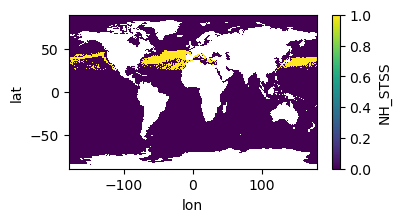

In [27]:
ds_biome['NH_STSS'] = ones.where(sst >= STSS_NH_temp_lothres).where(sst < STSS_NH_temp_upthres).where(ds_obs.lat > 25)

##### only one of two criteria for Chl and MLD must be met, so do it like this:
tmp = ds_biome['NH_STSS'].where(chl >= STSS_NH_chl_lothres).where(chl < STSS_NH_chl_upthres)
tmp = tmp.where(tmp > 0, other = 0)
tmp2 = ds_biome['NH_STSS'].where(mld > STSS_NH_mld_lothres)
tmp2 = tmp2.where(tmp2 > 0, other = 0)
tmp3 = (tmp + tmp2)
ds_biome['NH_STSS'] = ones.where(tmp3 >= 1)

### now make sure it doesn't overlap with SPSS biomes to the north
ds_biome['NH_STSS'] = ds_biome['NH_STSS'].where(ds_biome.NPac_SPSS < 1).where(ds_biome.NAtl_SPSS < 1)

ds_biome['NH_STSS'] = ds_biome['NH_STSS'].where(ds_biome['NH_STSS'] > 0, other = 0).where(ones > 0).compute()

ds_biome['NH_STSS'].plot(figsize=(4,2))

### Northern hemisphere Subtropical Permanently stratified (NH STPS) 

### (Atlantic and Pacific included, Indian is separate)

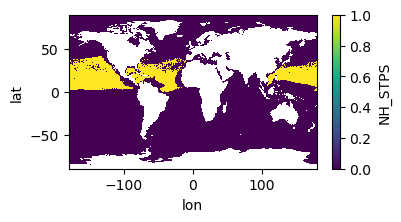

In [28]:
ds_biome['NH_STPS'] = ones.where(sst >= STPS_NH_temp_lothres).where(sst < STPS_NH_temp_upthres).where(ds_obs.lat > 0).where(Atlantic_Pacific == 1)

ds_biome['NH_STPS'] = ds_biome['NH_STPS'].where(chl < STPS_NH_chl_upthres)

ds_biome['NH_STPS'] = ds_biome['NH_STPS'].where(mld <= STPS_NH_mld_upthres)

### now make sure it doesn't overlap with STSS biome to the north
ds_biome['NH_STPS'] = ds_biome['NH_STPS'].where(ds_biome.NH_STSS < 1)

ds_biome['NH_STPS'] = ds_biome['NH_STPS'].where(ds_biome['NH_STPS'] > 0, other = 0) 

ds_biome['NH_STPS'] = ds_biome['NH_STPS'].where(ones > 0).compute()

ds_biome['NH_STPS'].plot(figsize=(4,2))

### Indian Subtropical Permanently stratified (IND STPS)

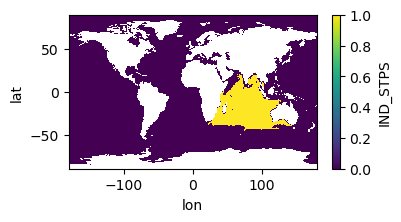

In [29]:
ds_biome['IND_STPS'] = ones.where(sst >= STPS_Ind_temp_lothres).where(chl < STPS_Ind_chl_upthres).where(Indian == 1)

ds_biome['IND_STPS'] = ds_biome['IND_STPS'].where(ds_biome['IND_STPS'] > 0, other = 0)

ds_biome['IND_STPS'] = ds_biome['IND_STPS'].where(ones > 0).compute()
                                               
ds_biome['IND_STPS'].plot(figsize=(4,2))

### West Pacific Equatorial regions (WPac_EQ)

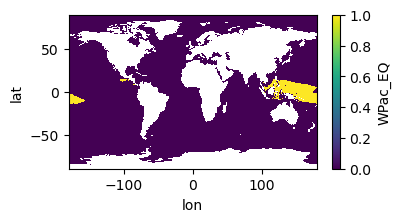

In [30]:
ds_biome['WPac_EQ'] = ones.where(sst > WPacEq_temp_lothres).where(ds_obs.lat >= -15).where(ds_obs.lat <= 15).where(Pacific == 1)
ds_biome['WPac_EQ'] = ds_biome['WPac_EQ'].where(chl < WPacEq_chl_upthres)

### Lastly, make sure it doesn't conflict with biome to the north
ds_biome['WPac_EQ'] = ds_biome['WPac_EQ'].where(ds_biome['NH_STPS'] < 1)

ds_biome['WPac_EQ'] = ds_biome['WPac_EQ'].where(ds_biome['WPac_EQ'] > 0, other = 0)

ds_biome['WPac_EQ'] = ds_biome['WPac_EQ'].where(ones > 0).compute()

ds_biome['WPac_EQ'].plot(figsize=(4,2))

### Eastern Pacific Equatorial region (EPac_EQ)

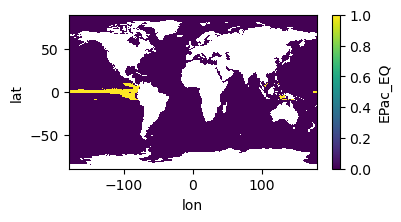

In [31]:
ds_biome['EPac_EQ'] = ones.where(sst >= EPacEq_temp_lothres).where(sst < EPacEq_temp_upthres).where(ds_obs.lat >= -10).where(ds_obs.lat <= 10).where(Pacific == 1)
ds_biome['EPac_EQ'] = ds_biome['EPac_EQ'].where(chl >= EPacEq_chl_lothres).where(chl < EPacEq_chl_upthres)

### Lastly, make sure it doesn't conflict with biome to the north
ds_biome['EPac_EQ'] = ds_biome['EPac_EQ'].where(ds_biome['NH_STPS'] < 1)

ds_biome['EPac_EQ'] = ds_biome['EPac_EQ'].where(ds_biome['EPac_EQ'] > 0, other = 0)

ds_biome['EPac_EQ'] = ds_biome['EPac_EQ'].where(ones > 0).compute()

ds_biome['EPac_EQ'].plot(figsize=(4,2))

### Equatorial Atlantic (Atl_EQ)

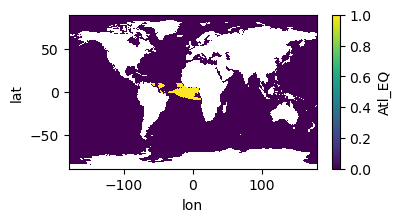

In [32]:
ds_biome['Atl_EQ'] = ones.where(sst >= AtlEq_temp_lothres).where(sst < AtlEq_temp_upthres).where(ds_obs.lat >= -10).where(ds_obs.lat <= 10).where(Atlantic == 1)
ds_biome['Atl_EQ'] = ds_biome['Atl_EQ'].where(chl >= AtlEq_chl_lothres).where(chl < AtlEq_chl_upthres)

### Lastly, make sure it doesn't conflict with biome to the north
ds_biome['Atl_EQ'] = ds_biome['Atl_EQ'].where(ds_biome['NH_STPS'] < 1)

ds_biome['Atl_EQ'] = ds_biome['Atl_EQ'].where(ds_biome['Atl_EQ'] > 0, other = 0)

ds_biome['Atl_EQ'] = ds_biome['Atl_EQ'].where(ones > 0).compute()

ds_biome['Atl_EQ'].plot(figsize=(4,2))

### Southern hemisphere ICE biome (SH ICE)

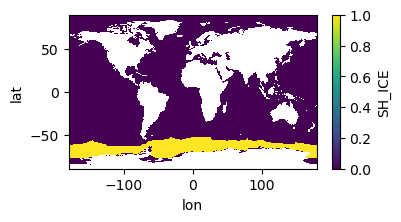

In [33]:
ds_biome['SH_ICE'] = ones.where(ice > ICE_lothres).where(ds_obs.lat < 0)

ds_biome['SH_ICE'] = ds_biome['SH_ICE'].where(ds_biome['SH_ICE'] > 0, other = 0)

ds_biome['SH_ICE'] = ds_biome['SH_ICE'].where(ones > 0).compute()

ds_biome['SH_ICE'].plot(figsize=(4,2))

### Southern hemisphere Subpolar seasonally stratified (SH SPSS)

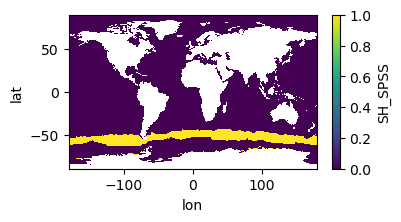

In [34]:
ds_biome['SH_SPSS'] = ones.where(sst < SPSS_SH_temp_upthres).where(ds_obs.lat < 0)

### Lastly, make sure it doesn't conflict with the SH ICE BIOME
ds_biome['SH_SPSS'] = ds_biome['SH_SPSS'].where(ds_biome['SH_ICE'] < 1)

ds_biome['SH_SPSS'] = ds_biome['SH_SPSS'].where(ds_biome['SH_SPSS'] > 0, other = 0)

ds_biome['SH_SPSS'] = ds_biome['SH_SPSS'].where(ones > 0).compute()

ds_biome['SH_SPSS'].plot(figsize=(4,2))

### Southern hemisphere Subtropical Seasonally Stratified (SH STSS)

#### I added that this one has to be south of 25°S (like the NH STSS has to be north of 25°N), otherwise this one extends to the equatorial regions

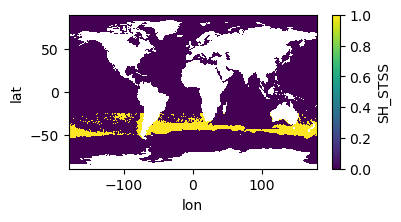

In [35]:
ds_biome['SH_STSS'] = ones.where(sst >= STSS_SH_temp_lothres).where(ds_obs.lat <= -25)

##### only one of two criteria for Chl and MLD must be met, so do it like this:
tmp = ds_biome['SH_STSS'].where(chl >= STSS_SH_chl_lothres)
tmp = tmp.where(tmp > 0, other = 0)
tmp2 = ds_biome['SH_STSS'].where(mld > STSS_SH_mld_lothres)
tmp2 = tmp2.where(tmp2 > 0, other = 0)
tmp3 = (tmp + tmp2)
ds_biome['SH_STSS'] = ones.where(tmp3 >= 1)

### now make sure it doesn't overlap with SPSS biomes to the north
ds_biome['SH_STSS'] = ds_biome['SH_STSS'].where(ds_biome.SH_SPSS < 1).where(ds_biome.NAtl_SPSS < 1).where(ds_biome.IND_STPS < 1)

ds_biome['SH_STSS'] = ds_biome['SH_STSS'].where(ds_biome['SH_STSS'] > 0, other = 0).where(ones > 0).compute()

ds_biome['SH_STSS'].plot(figsize=(4,2))

### Southern hemisphere subtropical permanently stratified (STPS)

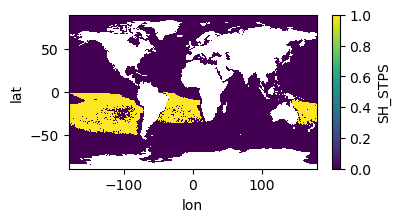

In [36]:
ds_biome['SH_STPS'] = ones.where(sst >= STPS_SH_temp_lothres).where(ds_obs.lat < 0)

ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(chl < STPS_SH_chl_upthres)

ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(mld <= STPS_SH_mld_upthres)

### now make sure it doesn't overlap with STSS biome to the south AND the Equatorial biomes to the north AND the Indian STPS
ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(ds_biome.SH_STSS < 1)
ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(ds_biome.Atl_EQ < 1).where(ds_biome.EPac_EQ < 1).where(ds_biome.WPac_EQ < 1)
ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(ds_biome.IND_STPS < 1)

ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(ds_biome['SH_STPS'] > 0, other = 0) 

ds_biome['SH_STPS'] = ds_biome['SH_STPS'].where(ones > 0).compute()

ds_biome['SH_STPS'].plot(figsize=(4,2))

### Add up all biomes make sure that they are not overlapping

In [37]:
%%time

ds_biome = ds_biome.load()

CPU times: user 67 μs, sys: 14 μs, total: 81 μs
Wall time: 109 μs


In [38]:
biomes = ['NH_ICE','NPac_SPSS','NAtl_SPSS',
          'NH_STSS','NH_STPS','IND_STPS','WPac_EQ',
          'EPac_EQ','Atl_EQ','SH_ICE','SH_SPSS','SH_STSS',
          'SH_STPS']

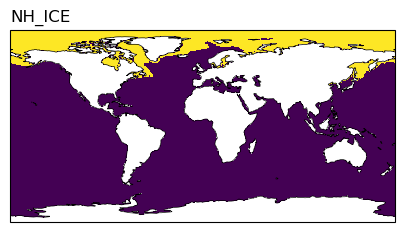

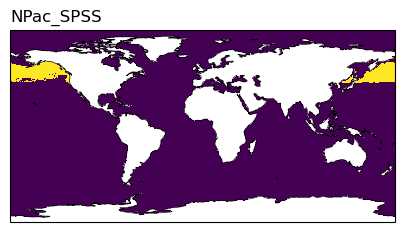

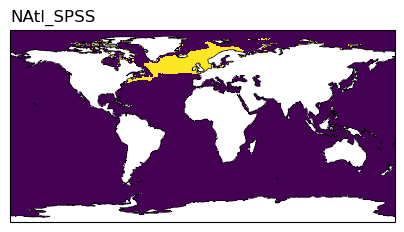

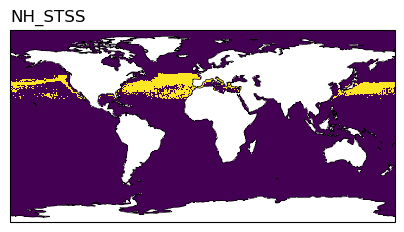

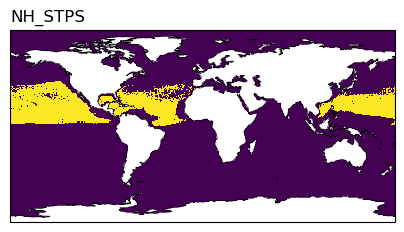

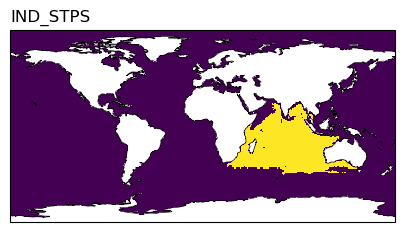

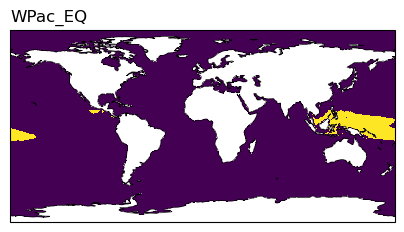

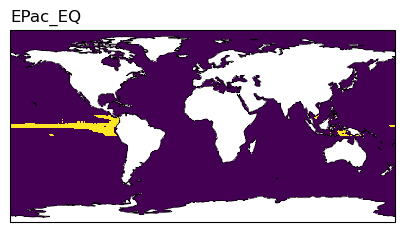

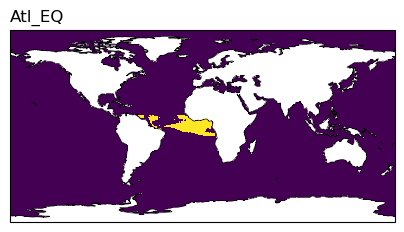

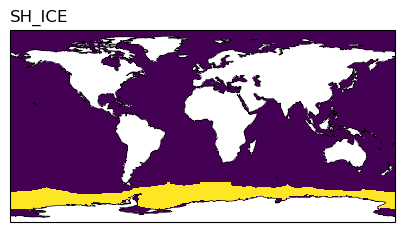

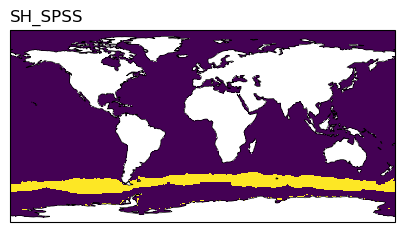

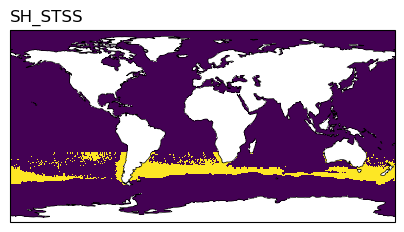

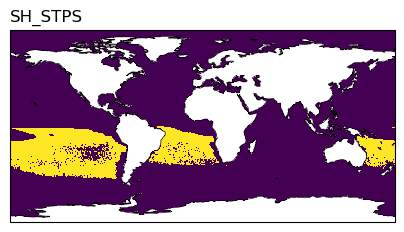

In [39]:
i = 0

for biome in biomes:
    if i == 0:
        biome_tot = ds_biome[biome]
    else:
        biome_tot = biome_tot + ds_biome[biome]

    fig = plt.figure(figsize=(5,2.5))
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    ax.coastlines('110m',linewidth=0.5)
    ax.set_title(biome, fontsize=12, loc='left')
    pc1=ax.pcolormesh(ds_obs.lon, ds_obs.lat, ds_biome[biome], cmap='viridis',
                      transform=ccrs.PlateCarree())

    plt.show()
    
    i = i + 1

### After several iterations (corrections) now each gridcell is only assigned to one biome

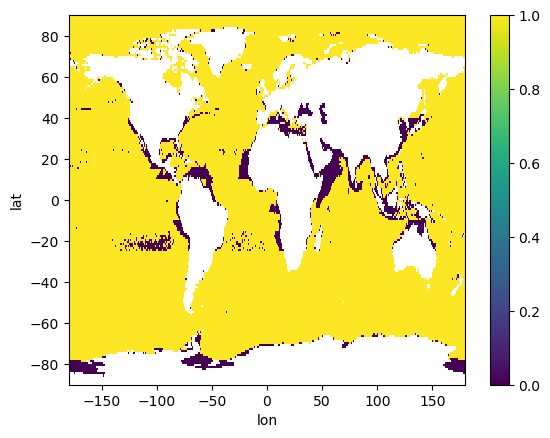

In [40]:
biome_tot.plot()

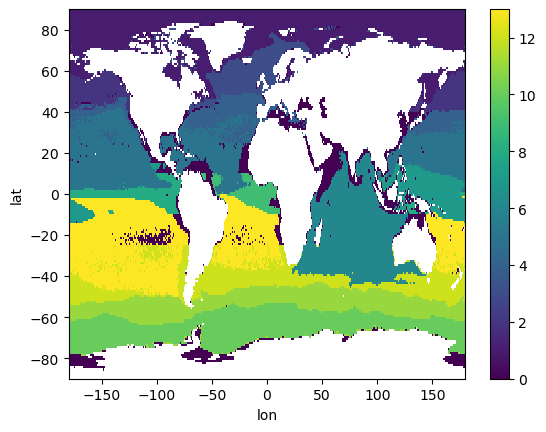

In [41]:
zeros = np.full((180,360),0,dtype=float)
zeros = xr.DataArray(zeros,dims=('lat','lon'))
zeros = zeros.where(land_mask == 1)

all_biomes = zeros

i = 1

for biome in biomes:
    all_biomes = (zeros + i).where(ds_biome[biome]==1,other=all_biomes)
    
    i = i + 1
    
all_biomes.plot()

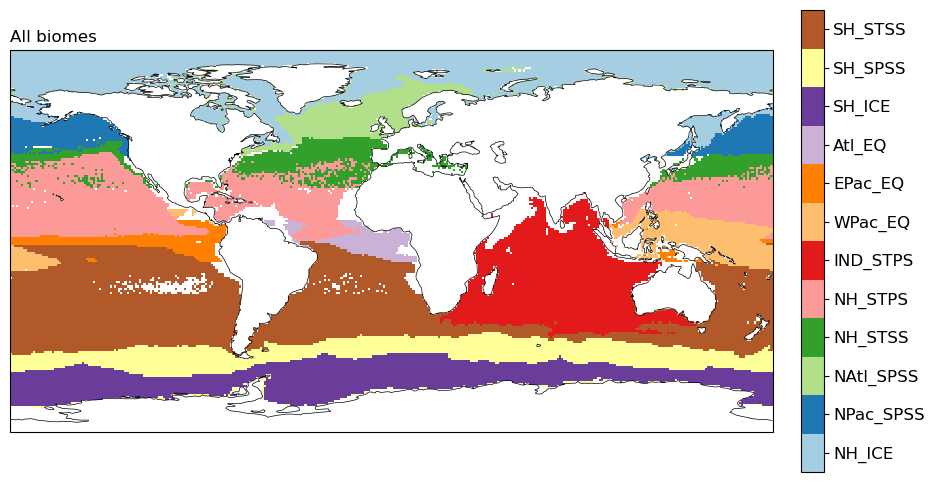

In [42]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines('110m',linewidth=0.5)
ax.set_title('All biomes', fontsize=12, loc='left')
pc1=ax.pcolormesh(ds_obs.lon, ds_obs.lat, all_biomes.where(all_biomes>0), cmap='Paired',
                  transform=ccrs.PlateCarree())
#pci=ax.contourf(lons, lats, all_biomes.where(all_biomes==0),levels=[0,0.99],transform=ccrs.PlateCarree(),hatches=['//'],colors='none')

cbar = fig.colorbar(pc1, ticks=np.arange(1.5,14,1), pad=0.03)
cbar.ax.set_yticklabels(biomes, fontsize=12) ;